In [1]:
import os
import zipfile
import pandas as pd
import glob
import numpy as np
import warnings
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import re

### Import chEMBL data for all viruses

In [4]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')

In [5]:
allVirusData_chEMBL = pd.read_csv(modelBuildingDataDir + 'AllVirusData_chEMBL_combined.csv')
allVirusData_chEMBL

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus
0,CHEMBL3753746,Nc1ncc(Br)c2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,C12H13BrN4O3,XGHPFIDDLHHTKE-ORCOQGSOSA-N,InChI=1S/C12H13BrN4O3/c13-6-2-15-12(14)8-9(6)1...,341.17,Small molecule,NaN,NaN,NaN,...,4.0,2.0,0.61,20.0,2.0,0.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah
1,CHEMBL3754027,Nc1ncc(Br)c2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H13BrN4O3,XGHPFIDDLHHTKE-UTBOHETQSA-N,InChI=1S/C12H13BrN4O3/c13-6-2-15-12(14)8-9(6)1...,341.17,Small molecule,NaN,NaN,NaN,...,4.0,2.0,0.61,20.0,2.0,0.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah
2,CHEMBL556461,NC(=O)C1CCN(c2cc3c(cc2F)c(=O)c(C(=O)NCc2ccc(Cl...,C26H25Cl2FN4O3,WJOHCLQFSHPICB-UHFFFAOYSA-N,InChI=1S/C26H25Cl2FN4O3/c27-16-2-1-15(20(28)9-...,531.42,Small molecule,NaN,NaN,NaN,...,2.0,6.0,0.49,36.0,3.0,1.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah
3,CHEMBL214087,Nc1ccc2oc(Cc3ccccc3)nc2c1,C14H12N2O,KYWJNXDUENQSPB-UHFFFAOYSA-N,InChI=1S/C14H12N2O/c15-11-6-7-13-12(9-11)16-14...,224.26,Small molecule,NaN,NaN,NaN,...,1.0,2.0,0.68,17.0,3.0,0.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah
4,CHEMBL2016757,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@H](CO)[C@@H](O)...,C12H13N5O4,BRDWIEOJOWJCLU-LTGWCKQJSA-N,InChI=1S/C12H13N5O4/c13-4-12(10(20)9(19)7(3-18...,291.27,Small molecule,2120.0,nM,'=',...,4.0,2.0,0.50,21.0,2.0,0.0,CHEMBL615055,Nipah virus,Henipavirus nipahense,Nipah
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,CHEMBL1631739,CCC(Sc1nc2ccsc2c(=O)n1Cc1ccc2c(c1)OCO2)C(=O)NC...,C23H21N3O5S2,IXNBENOPJYMMQU-UHFFFAOYSA-N,InChI=1S/C23H21N3O5S2/c1-2-19(21(27)24-11-15-4...,483.57,Small molecule,41.0,%,'=',...,1.0,8.0,0.30,33.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta
2065,CHEMBL1631743,O=C(CSc1nc2nccnc2c(=O)n1Cc1cccs1)NCCc1ccccc1,C21H19N5O2S2,KAXCHLAOBYVWBT-UHFFFAOYSA-N,InChI=1S/C21H19N5O2S2/c27-17(22-9-8-15-5-2-1-3...,437.55,Small molecule,6.0,%,'=',...,1.0,8.0,0.34,30.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta
2066,CHEMBL1632515,Cc1cc(C)cc(-n2c(=O)c3sccc3n(CC(=O)N3CCN(c4cccc...,C26H26N4O3S,VAAJVHVMOKTAQL-UHFFFAOYSA-N,InChI=1S/C26H26N4O3S/c1-18-14-19(2)16-21(15-18...,474.59,Small molecule,2.2,%,'=',...,0.0,4.0,0.46,34.0,4.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta
2067,CHEMBL1632518,O=C(Cn1c(=O)n(Cc2ccco2)c(=O)c2sc3ccccc3c21)NCc...,C24H18ClN3O4S,RJTMADKPFKESDQ-UHFFFAOYSA-N,InChI=1S/C24H18ClN3O4S/c25-16-9-7-15(8-10-16)1...,479.95,Small molecule,0.0,%,'=',...,1.0,6.0,0.40,33.0,5.0,0.0,CHEMBL1907598,Integrin alpha-V/beta-3,Homo sapiens,Hanta


### Count Standard Type

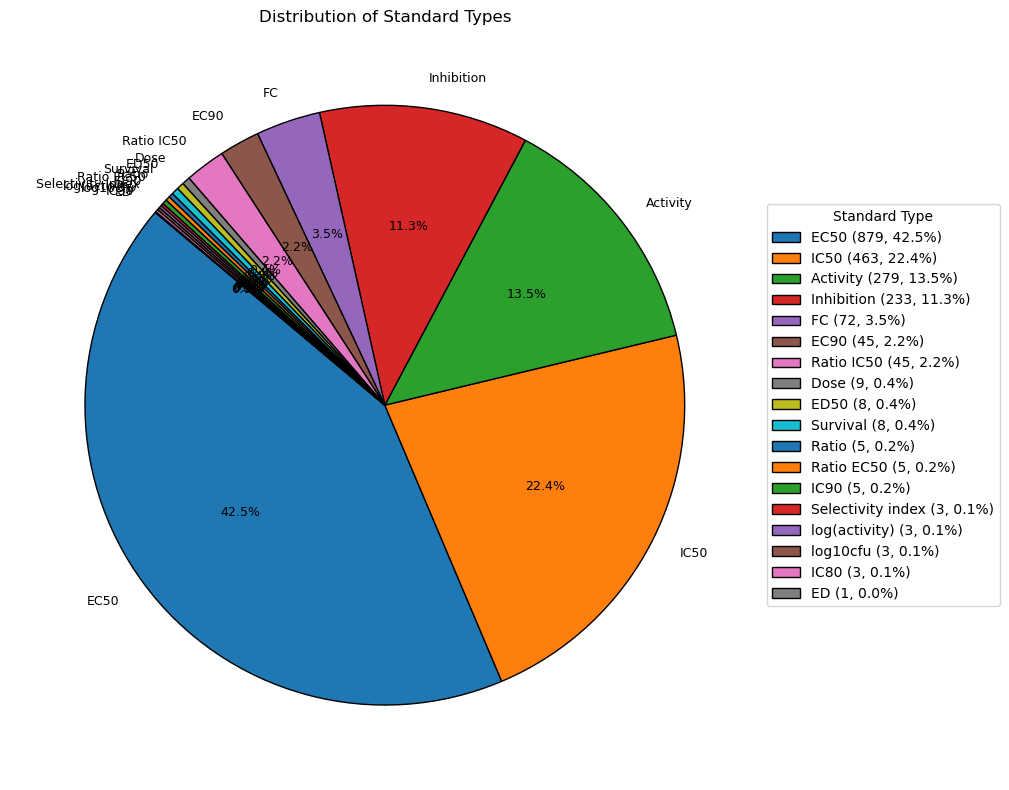

In [6]:
# Count occurrences of each Standard Type
type_counts = allVirusData_chEMBL["standard_type"].value_counts()
total = type_counts.sum()

# Legend labels with counts and percentages
legend_labels = [
    f"{stype} ({count}, {count/total:.1%})"
    for stype, count in type_counts.items()
]

# Plot pie chart with inside labels showing just Standard Type
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    type_counts,
    labels=type_counts.index,  # short labels inside slices
    autopct='%1.1f%%',         # show % inside too
    startangle=140,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 9}
)

# Legend with full details
plt.legend(
    wedges,
    legend_labels,
    title="Standard Type",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Distribution of Standard Types")
plt.tight_layout()
plt.show()